In [3]:
!pip install pandas scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [5]:
df = pd.read_csv("C:/Users/My Pc/Desktop/deveoplershubcorp/cleaned_merged_heart_dataset.csv")

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
df.isnull().sum()
# If missing:
df = df.dropna()

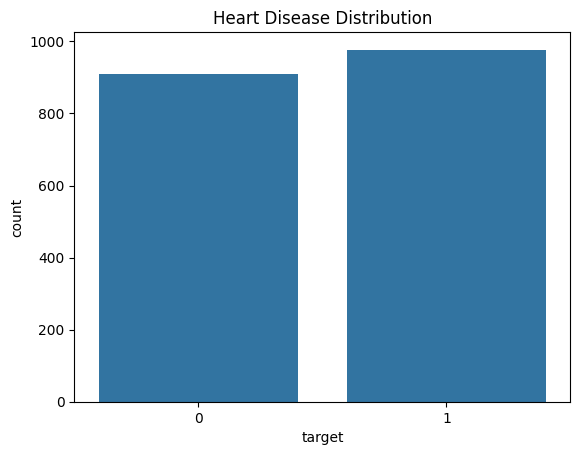

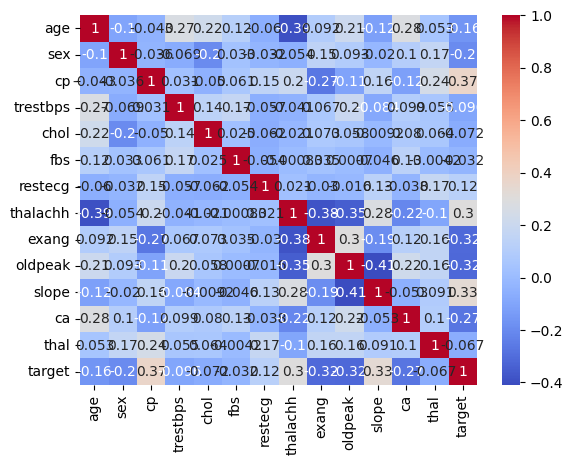

In [8]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [11]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

In [12]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))

Logistic Regression Accuracy: 0.7248677248677249
Decision Tree Accuracy: 0.9444444444444444


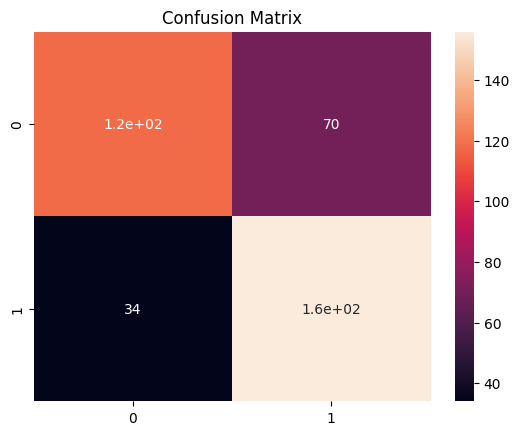

In [13]:
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

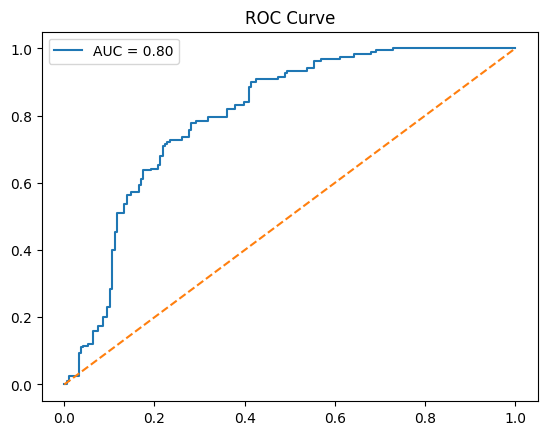

In [14]:
lr_probs = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = roc_auc_score(y_test, lr_probs)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

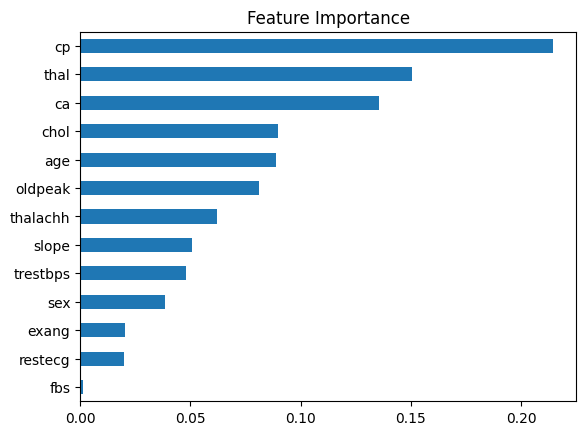

In [15]:
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()